# Ex.No.6 - Multi Layer Perceptron

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 10/03/2026_

In [35]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

In [37]:
# Inputs
X = np.array([[1,1,0,1]])
y = np.array([[1]])

# Input to Hidden layer weights
w_input_hidden = np.array([
    [0.3,0.1],
    [-0.2,0.4],
    [0.2,-0.3],
    [0.1,0.4]
])

# Hidden to Output layer weights
w_hidden_output = np.array([
    [-0.3],
    [0.2]
])

# Bias values
b_hidden = np.array([[0.2,0.1]])
b_output = np.array([[-0.3]])

In [38]:
# Training parameters
lr = 1.5
epochs = 10
errors = []

In [39]:
# Training loop
for epoch in range(epochs):

    total_error = 0

    print("\nEpoch", epoch+1)

    for i in range(len(X)):

        # Forward pass
        hidden_net = np.dot(X[i], w_input_hidden) - b_hidden
        hidden_out = sigmoid(hidden_net)

        output_net = np.dot(hidden_out, w_hidden_output) - b_output
        output = sigmoid(output_net)

        # Error
        error = y[i] - output
        total_error += np.sum(error**2)

        print("Input:", X[i])
        print("Output:", output)
        print("Error:", error)

        # Backpropagation
        d_output = error * sigmoid_derivative(output)
        d_hidden = d_output.dot(w_hidden_output.T) * sigmoid_derivative(hidden_out)

        # Weight update
        w_hidden_output += lr * hidden_out.reshape(-1,1) * d_output
        w_input_hidden += lr * X[i].reshape(-1,1) * d_hidden

        b_output -= lr * d_output
        b_hidden -= lr * d_hidden

    errors.append(total_error)
    print("Total Error:", total_error)

    if total_error < 0.05:
        break


Epoch 1
Input: [1 1 0 1]
Output: [[0.57150518]]
Error: [[0.42849482]]
Total Error: 0.1836078110925363

Epoch 2
Input: [1 1 0 1]
Output: [[0.63739074]]
Error: [[0.36260926]]
Total Error: 0.13148547742613914

Epoch 3
Input: [1 1 0 1]
Output: [[0.6866325]]
Error: [[0.3133675]]
Total Error: 0.09819918934337848

Epoch 4
Input: [1 1 0 1]
Output: [[0.72364424]]
Error: [[0.27635576]]
Total Error: 0.0763725048154056

Epoch 5
Input: [1 1 0 1]
Output: [[0.75207877]]
Error: [[0.24792123]]
Total Error: 0.06146493660227163

Epoch 6
Input: [1 1 0 1]
Output: [[0.77447647]]
Error: [[0.22552353]]
Total Error: 0.05086086462747115

Epoch 7
Input: [1 1 0 1]
Output: [[0.79253714]]
Error: [[0.20746286]]
Total Error: 0.04304083904467565


In [40]:
# Final weights
print("Final Input→Hidden Weights:\n", w_input_hidden)
print("Final Hidden→Output Weights:\n", w_hidden_output)

print("Final Hidden Bias:", b_hidden)
print("Final Output Bias:", b_output)

Final Input→Hidden Weights:
 [[ 0.27295681  0.15180705]
 [-0.22704319  0.45180705]
 [ 0.2        -0.3       ]
 [ 0.07295681  0.45180705]]
Final Hidden→Output Weights:
 [[0.01343491]
 [0.65549014]]
Final Hidden Bias: [[0.22704319 0.04819295]]
Final Output Bias: [[-0.9467433]]


In [41]:
# Testing
hidden = sigmoid(np.dot(X, w_input_hidden) - b_hidden)
output = sigmoid(np.dot(hidden, w_hidden_output) - b_output)

print("Predicted Output:", output)

Predicted Output: [[0.80740401]]


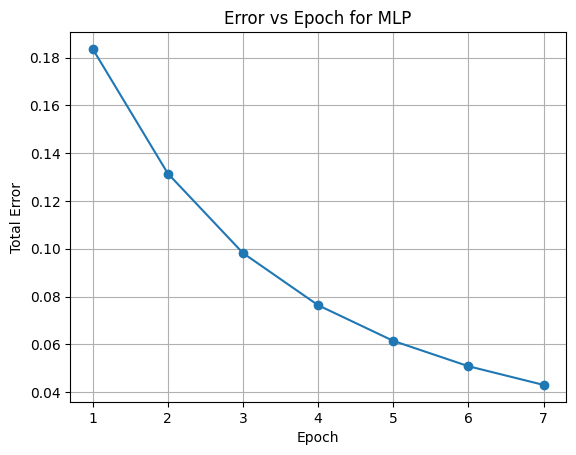

In [42]:
# Error graph
plt.plot(range(1, len(errors)+1), errors, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Total Error")
plt.title("Error vs Epoch for MLP")

plt.xticks(range(1, len(errors)+1))
plt.grid(True)

plt.show()